gitHub: https://github.com/TianhaoZhao-9/stat359/tree/main/student/final_project/tinystories_llm

## Background
Large language models (LLMs) are typically pre-trained on large text corpora using next-token prediction, enabling strong language understanding and generation capabilities. However, pre-trained models often lack control over response style and instruction-following behavior. Instruction tuning addresses this limitation by training models on prompt–response pairs, improving both task performance and alignment with user intent. Recent work suggests that instruction datasets can also influence stylistic features such as tone, vocabulary, and response structure, leading to the concept of persona engineering. This project investigates whether such stylistic behaviors are primarily driven by instruction data rather than training duration.

## Introduction

Instruction tuning allows language models to adapt their behavior by training on curated prompt–response pairs. In addition to improving task completion, instruction tuning can also influence stylistic characteristics such as vocabulary, tone, and response structure. This project investigates whether instruction-tuning datasets can produce distinct conversational personas in a language model. Using the TinyStories GPT-style model as the base model, two persona-specific instruction datasets were constructed: a Pirate assistant and a Technical Writer assistant. To isolate the effect of persona data, a control model trained for additional epochs without persona instructions was also included. The experiment compares these models to determine whether stylistic behavior emerges primarily from instruction data rather than training duration.

## Methodology

#### Model and Training Setup

All experiments are based on the TinyStories GPT-style language model provided in the course framework. The base model was first trained on the TinyStories dataset and then instruction-tuned using conversation-style datasets. Training was performed using the provided script train_tinystories_chat_model.py, which fine-tunes a pretrained model using conversation pairs in the format: text: user prompt, text: assistant response per conversation. The training objective is next-token prediction over the conversation sequence, allowing the model to learn both task completion and stylistic response patterns. The only differences across models were the instruction dataset used and the number of training epochs.

#### Persona Dataset Construction

Two instruction-tuning datasets were constructed to induce different response styles. The Pirate dataset encourages the model to respond using pirate-themed language while still completing the user’s task. Responses contain characteristic pirate vocabulary and informal tone while maintaining clear answers. The Technical Writer dataset represents the opposite style, emphasizing clarity, structure, and professional language. Responses typically provide concise explanations, structured reasoning, or step-by-step guidance. To ensure stylistic effects are consistent across tasks, prompts were divided into three categories: storytelling, explanation and practical advice. Each dataset contains approximately 3000 examples, balanced across these prompt types. Prompt templates and vocabulary pools were used to generate diverse examples while preserving consistent task structure.

#### Experimental Design
Four models were evaluated: Default, Pirate, Techwriter and Moreepochs. The MoreEpochs model acts as a control experiment to test whether stylistic changes arise from longer training rather than persona-specific data. To ensure fair comparison, all models were evaluated using the same set of 20 prompts, covering storytelling, explanation, and advice tasks. During training, loss curves were monitored to confirm stable optimization and comparable convergence behavior across models. From the output perspective, I will evaluate all models using a fixed set of 20 prompts covering storytelling, explanation, and advice tasks. Then, compare outputs across models in terms of style consistency, structural stability, and vocabulary distribution. Specifically, I compute persona keyword frequency ratios and average sentence length to quantify stylistic differences, then comparing embedding similarity and compliance test to further evaluate deeper behavioral differences beyond surface-level style.

#### Foundation model instruct tuning loss

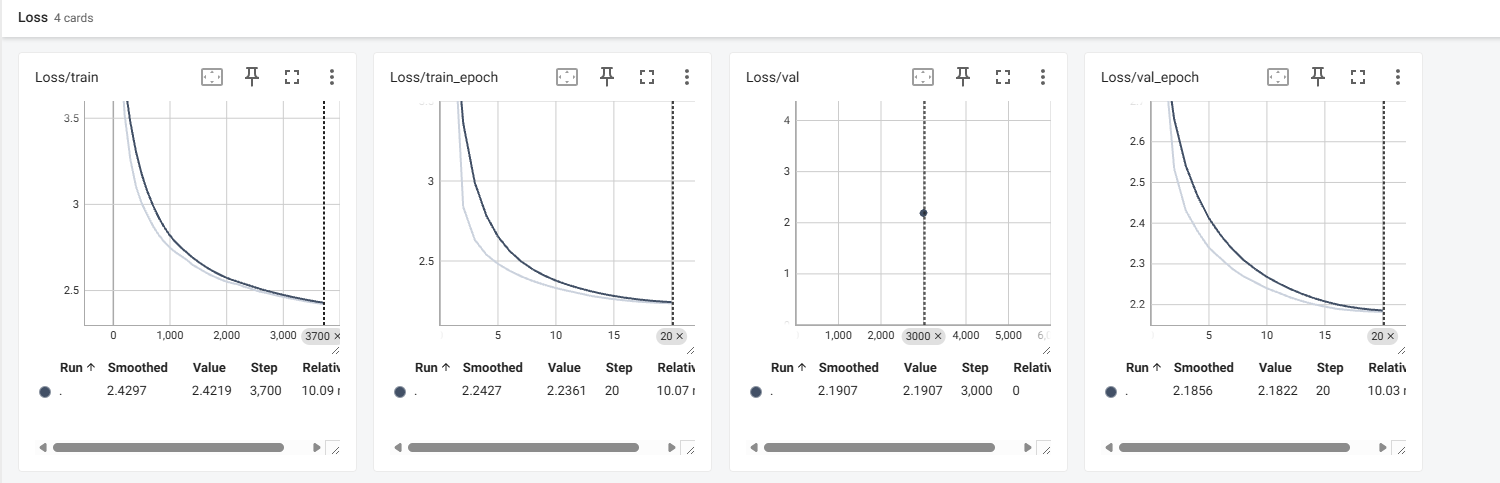

In [5]:
display(Image("loss_output/foundation_tuning_loss.png"))

#### Pirate dataset instruction tuning

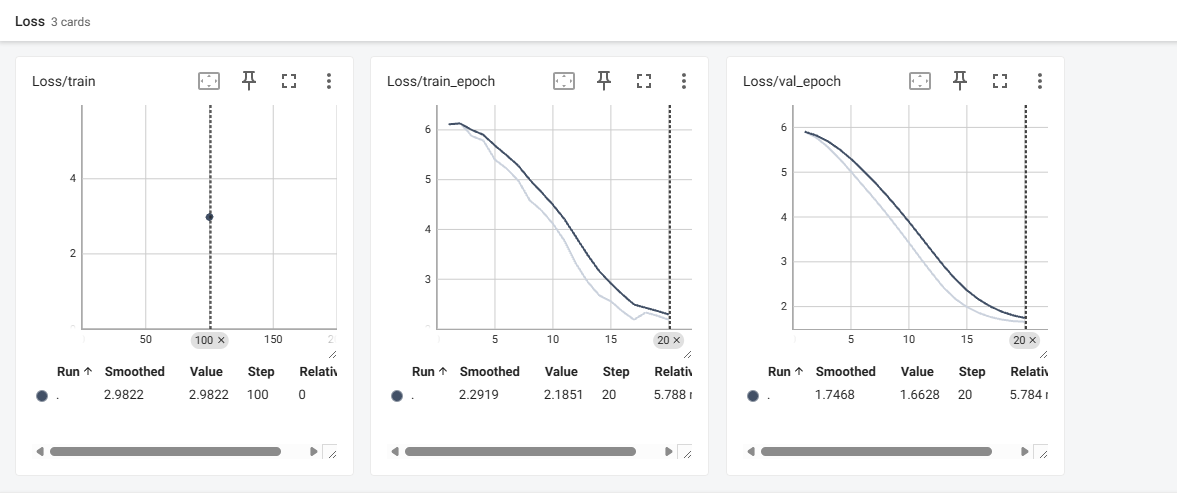

In [6]:
display(Image("loss_output/pirate_data.png"))

#### Technical writer loss curve

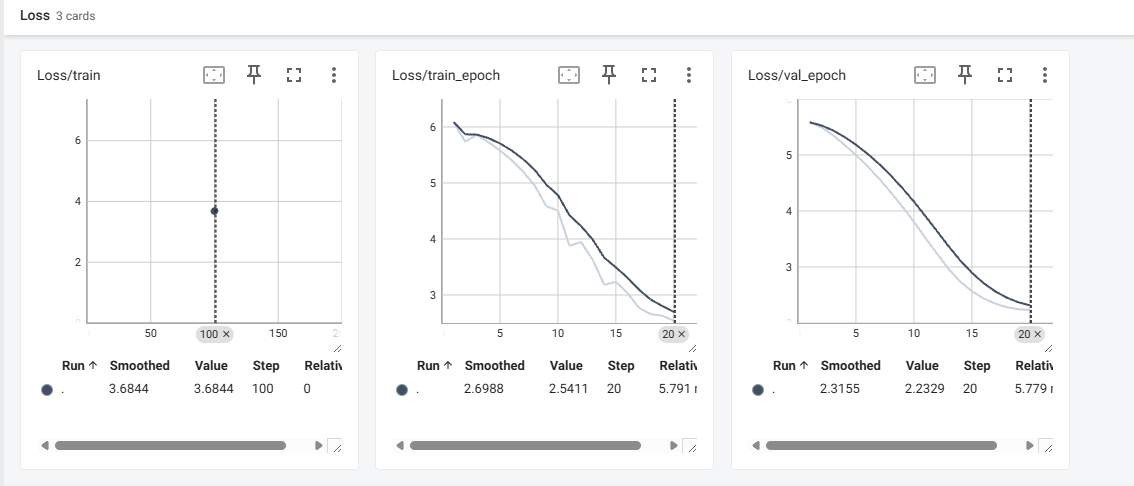

In [7]:
display(Image("loss_output/techwriter_data.png"))

During instruction tuning, training and validation losses decreased steadily across all models, indicating stable convergence. For the Technical Writer model, training loss decreased from approximately 6.0 to 2.54 while validation loss declined from about 5.8 to 2.23. The Pirate model showed a similar trend, with training loss dropping from roughly 6.1 to 2.19 and validation loss decreasing from about 5.9 to 1.66. For the default model, training loss decreased from approximately 3.6 to 2.24 while validation loss declined from around 2.7 to 2.18 over the training period. In all cases, validation loss remains close to or slightly lower than training loss at the end of training, suggesting stable optimization and no clear evidence of overfitting.

## Results

#### example output 

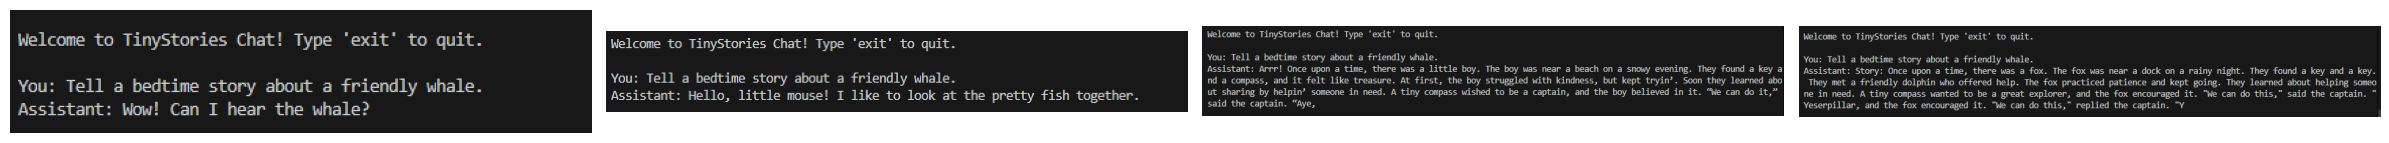

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# File paths
images = [
    "model_output/default_output.png",
    "model_output/more_epoch_output.png",
    "model_output/pirate_output.png",
    "model_output/techwriter_output.png",
]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, img_path in zip(axes, images):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

Across the same prompt, the four models exhibit clearly differentiated behaviors. The default chat model fails to follow the instruction properly, often responding with a meta-style or short conversational reply rather than producing a coherent story, indicating weak instruction alignment. The “more epochs” version of the default model shows slight improvement in fluency and narrative continuation, but it still does not consistently adhere to the requested structure or content constraints, suggesting that simply increasing training time does not meaningfully strengthen instruction-following ability. In contrast, the pirate persona model strongly conditions on stylistic cues (“Ahoy,” “Yo-ho-ho”) and reliably produces story-like outputs, demonstrating that instruction data can significantly shift both tone and structural compliance. The tech-writer model generates more formal and explanatory language, showing clearer structural intent, though sometimes at the expense of narrative creativity. Overall, these examples support the project hypothesis that changing instruction data (persona engineering) has a larger behavioral impact than merely extending training epochs or change any training setting under the same data distribution.


#### keyword frequency ratio & AVG length

In [2]:
import pandas as pd

data = {
    "Model": [
        "Default",
        "Default (More Epochs)",
        "Pirate",
        "TechWriter"
    ],
    "Total Words": [
        3966,
        3902,
        8724,
        9123
    ],
    "Avg Sentence Length": [
        6.31,
        6.32,
        7.72,
        9.51
    ],
    "Pirate Keyword Ratio": [
        0.0003,
        0.0003,
        0.0454,
        0.0004
    ],
    "Tech Keyword Ratio": [
        0.0050,
        0.0051,
        0.0045,
        0.0195
    ]
}

df = pd.DataFrame(data)

print(df)

                   Model  Total Words  Avg Sentence Length  \
0                Default         3966                 6.31   
1  Default (More Epochs)         3902                 6.32   
2                 Pirate         8724                 7.72   
3             TechWriter         9123                 9.51   

   Pirate Keyword Ratio  Tech Keyword Ratio  
0                0.0003              0.0050  
1                0.0003              0.0051  
2                0.0454              0.0045  
3                0.0004              0.0195  


To measure stylistic differences between models, we computed the frequency ratio of persona-specific keywords within generated outputs. Pirate-related vocabulary (e.g., “arrr”, “matey”) and technical writing vocabulary (e.g., “definition”, “explain”, "concept") were counted and normalized by the total number of generated words.
The results are shown in Table. The Pirate model shows a substantially higher pirate keyword ratio (0.0454) compared with the baseline models, which exhibit almost no pirate-style vocabulary (0.0003). Similarly, the Technical Writer model produces the highest technical keyword ratio (0.0195), significantly exceeding the baseline models. Importantly, the model trained with additional epochs but without persona data shows nearly identical keyword ratios to the default model. This suggests that stylistic vocabulary does not emerge simply from longer training, but rather from targeted instruction datasets.

#### Compliance_test

In [3]:
data = {
    "Model": [
        "Default",
        "Default (More Epochs)",
        "Pirate",
        "TechWriter"
    ],
    "Compliance Rate": [
        0.15,
        0.25,
        1.00,
        0.75
    ],
    "Compliant / Total": [
        "3/20",
        "5/20",
        "20/20",
        "15/20"
    ]
}

df = pd.DataFrame(data)

print(df)

                   Model  Compliance Rate Compliant / Total
0                Default             0.15              3/20
1  Default (More Epochs)             0.25              5/20
2                 Pirate             1.00             20/20
3             TechWriter             0.75             15/20


To evaluate whether the generated responses follow the intended task instructions, we measure the compliance rate, defined as the proportion of prompts for which the model output satisfies predefined task requirements. The evaluation rules are implemented programmatically and vary by prompt category.
The first seven prompts correspond to story generation tasks. A response is considered compliant if it produces a sufficiently long narrative, defined as either at least three sentences or at least 35 words. Prompts 8–14 correspond to explanation tasks. For these prompts, a response is labeled compliant if it contains at least two sentences and at least 20 words, ensuring that the model provides a meaningful explanation rather than a short or incomplete statement. Prompts 15–20 correspond to advice tasks. A response is considered compliant if it contains at least two sentences and includes advice-related keywords, indicating that the response provides actionable suggestions rather than unrelated text.
The compliance results are summarized in Table X. The baseline model achieves a compliance rate of 15% (3/20 prompts), indicating that it frequently fails to produce outputs that satisfy the task requirements. Training the same model for additional epochs slightly improves the compliance rate to 25%, but the improvement remains limited. 
In contrast, the persona-tuned models show substantially higher compliance. The Pirate model achieves perfect compliance (20/20), while the Technical Writer model successfully completes 75% of the prompts. These results suggest that instruction-tuning datasets not only influence stylistic vocabulary but also significantly improve the model’s ability to produce task-relevant responses.

#### Embedding similarity

In [4]:
data = {
    "Model": [
        "Default",
        "Pirate",
        "TechWriter",
        "Default (More Epochs)"
    ],
    "Average Embedding Similarity": [
        0.075809,
        0.351289,
        0.153872,
        0.089439
    ]
}

df = pd.DataFrame(data)

print(df)

                   Model  Average Embedding Similarity
0                Default                      0.075809
1                 Pirate                      0.351289
2             TechWriter                      0.153872
3  Default (More Epochs)                      0.089439


To measure how closely each model’s responses align with the intended persona style, we compute embedding similarity between generated outputs and reference descriptions of each persona. Specifically, each response is converted into a sentence embedding using the all-MiniLM-L6-v2 model from the SentenceTransformers library. The cosine similarity between the response embedding and a reference embedding describing the target persona style is then calculated. The reported value represents the average cosine similarity across all prompts for each model.  
The Pirate model achieves the highest similarity score (0.3513), indicating that its generated responses align most strongly with the pirate-style reference description. The Technical Writer model also shows increased similarity to its corresponding reference style compared with the baseline model. In contrast, the default model exhibits very low similarity (0.0758), suggesting that its responses remain largely neutral and do not strongly reflect any specific persona. The model trained for additional epochs without persona data shows only a small increase in similarity (0.0894) relative to the default model. This result reinforces the earlier findings that stylistic behavior does not emerge simply from longer training. Instead, the instruction-tuning datasets appear to play a primary role in shaping the model’s response style.
Overall, the embedding similarity results provide additional evidence that persona-specific instruction data can meaningfully influence the semantic characteristics of generated responses.

## Conclusion and limitations

This project demonstrates that instruction-tuning datasets play a significant role in shaping language model behavior. The results show that persona-specific datasets can produce clear stylistic differences in vocabulary, response structure, and instruction compliance, while simply extending training duration does not lead to similar effects. These findings suggest that persona engineering through instruction tuning is an effective approach for controlling model behavior.
However, several limitations remain. The persona datasets were generated using templates, the evaluation relied on a relatively small set of 20 prompts with rule-based compliance metrics, and only two personas were tested. These factors may limit the diversity of the generated responses and the generalizability of the results.
Future work could extend this study by using larger and more diverse datasets, exploring additional persona styles, and incorporating more advanced automatic or human-based evaluation methods.